In [11]:
# ============================================
# IMPORT ALL LIBRARIES - Run this first!
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import joblib
import re
import os

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("✅ All libraries imported!")

✅ All libraries imported!


📊 SPAM EMAIL DETECTION - COMPLETE EVALUATION

📂 Loading and processing data...
📝 Applying TF-IDF...
✅ Features shape: (4457, 5000)
💾 Saving files...
✅ Files saved!

📊 TRAINING MODELS

🔹 Logistic Regression...
   Accuracy: 0.9722, F1: 0.8839

🔹 Random Forest...
   Accuracy: 0.9767, F1: 0.9044

🔹 SVM...
   Accuracy: 0.9848, F1: 0.9404

🏆 BEST MODEL: SVM with Accuracy: 0.9848

📊 Confusion Matrix:


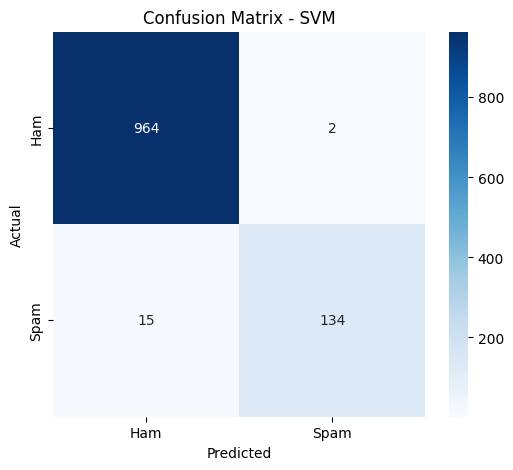


Confusion Matrix Values:
True Negatives (Ham correct):     964
False Positives (Ham as Spam):    2
False Negatives (Spam as Ham):    15
True Positives (Spam correct):    134

📋 Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115


✅ Saved: results/model_comparison.csv
✅ Saved: models/best_model.pkl

📊 Model Comparison Chart:


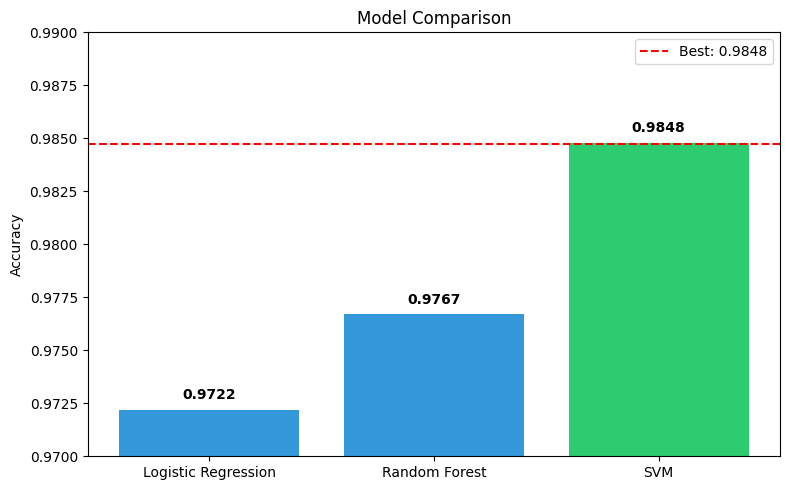


🔍 TESTING MODEL WITH NEW MESSAGES

📧 Message: Congratulations! You've won a free iPhone! Click here t...
📊 Prediction: SPAM

📧 Message: Hey, are we still meeting for lunch tomorrow?...
📊 Prediction: HAM

📧 Message: URGENT: Your account has been compromised! Verify now!...
📊 Prediction: SPAM

📧 Message: Can you please send me the assignment by evening?...
📊 Prediction: HAM

📧 Message: FREE MONEY! Click this link to get $1000 instantly!...
📊 Prediction: SPAM

📧 Message: Don't forget to submit your project by Friday....
📊 Prediction: HAM

✅ PROJECT COMPLETED SUCCESSFULLY!

📊 RESULTS SUMMARY:
-------------------
• Best Model: SVM
• Accuracy:  98.48%
• Precision: 98.53%
• Recall:    89.93%
• F1-Score:  94.04%

📁 FILES CREATED:
-------------------
✅ data/sms_spam_processed.csv
✅ data/X_train_tfidf.npz
✅ data/X_test_tfidf.npz
✅ models/tfidf_vectorizer.pkl
✅ models/best_model.pkl
✅ results/model_comparison.csv

🎯 PROJECT STATUS:
-------------------
✅ Data Preprocessing - COMPLETE
✅ Feature En

In [12]:
# ============================================
# COMPLETE EVALUATION - Run this one cell!
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import joblib
import re
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("📊 SPAM EMAIL DETECTION - COMPLETE EVALUATION")
print("="*60)

# ============================================
# CREATE FOLDERS
# ============================================
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# ============================================
# LOAD AND PROCESS DATA
# ============================================
print("\n📂 Loading and processing data...")

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_message'] = df['message'].apply(clean_text)
df['label_binary'] = df['label'].map({'spam': 1, 'ham': 0})

# Split data
X = df['cleaned_message']
y = df['label_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
print("📝 Applying TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"✅ Features shape: {X_train_tfidf.shape}")

# Save files
print("💾 Saving files...")
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
scipy.sparse.save_npz('data/X_train_tfidf.npz', X_train_tfidf)
scipy.sparse.save_npz('data/X_test_tfidf.npz', X_test_tfidf)
np.save('data/y_train.npy', y_train.values)
np.save('data/y_test.npy', y_test.values)
df.to_csv('data/sms_spam_processed.csv', index=False)
print("✅ Files saved!")

# ============================================
# TRAIN MODELS
# ============================================
print("\n" + "="*50)
print("📊 TRAINING MODELS")
print("="*50)

results = []

# Logistic Regression
print("\n🔹 Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print(f"   Accuracy: {acc_lr:.4f}, F1: {f1_lr:.4f}")

# Random Forest
print("\n🔹 Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
print(f"   Accuracy: {acc_rf:.4f}, F1: {f1_rf:.4f}")

# SVM
print("\n🔹 SVM...")
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
print(f"   Accuracy: {acc_svm:.4f}, F1: {f1_svm:.4f}")

# Find best model
models_dict = {
    'Logistic Regression': (lr, y_pred_lr, acc_lr, prec_lr, rec_lr, f1_lr),
    'Random Forest': (rf, y_pred_rf, acc_rf, prec_rf, rec_rf, f1_rf),
    'SVM': (svm, y_pred_svm, acc_svm, prec_svm, rec_svm, f1_svm)
}

best_name = max(models_dict, key=lambda x: models_dict[x][2])
best_model, best_pred, best_acc, best_prec, best_rec, best_f1 = models_dict[best_name]

print(f"\n🏆 BEST MODEL: {best_name} with Accuracy: {best_acc:.4f}")

# ============================================
# CONFUSION MATRIX
# ============================================
print("\n📊 Confusion Matrix:")

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nConfusion Matrix Values:")
print(f"True Negatives (Ham correct):     {cm[0,0]}")
print(f"False Positives (Ham as Spam):    {cm[0,1]}")
print(f"False Negatives (Spam as Ham):    {cm[1,0]}")
print(f"True Positives (Spam correct):    {cm[1,1]}")

# ============================================
# CLASSIFICATION REPORT
# ============================================
print("\n📋 Classification Report:")
print(classification_report(y_test, best_pred, target_names=['Ham', 'Spam']))

# ============================================
# SAVE RESULTS
# ============================================
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': acc_lr, 'Precision': prec_lr, 'Recall': rec_lr, 'F1': f1_lr},
    {'Model': 'Random Forest', 'Accuracy': acc_rf, 'Precision': prec_rf, 'Recall': rec_rf, 'F1': f1_rf},
    {'Model': 'SVM', 'Accuracy': acc_svm, 'Precision': prec_svm, 'Recall': rec_svm, 'F1': f1_svm}
])
comparison = comparison.round(4)
comparison.to_csv('results/model_comparison.csv', index=False)
print("\n✅ Saved: results/model_comparison.csv")

# Save best model
joblib.dump(best_model, 'models/best_model.pkl')
print("✅ Saved: models/best_model.pkl")

# ============================================
# MODEL COMPARISON CHART
# ============================================
print("\n📊 Model Comparison Chart:")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if m == best_name else '#3498db' for m in comparison['Model']]
bars = ax.bar(comparison['Model'], comparison['Accuracy'], color=colors)
ax.set_ylim(0.97, 0.99)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison')
ax.axhline(y=best_acc, color='red', linestyle='--', label=f'Best: {best_acc:.4f}')
ax.legend()

for bar, acc in zip(bars, comparison['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{acc:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# TEST WITH NEW MESSAGES
# ============================================
print("\n🔍 TESTING MODEL WITH NEW MESSAGES")
print("="*50)

def predict_spam(message):
    cleaned = clean_text(message)
    transformed = tfidf.transform([cleaned])
    pred = best_model.predict(transformed)[0]
    return "SPAM" if pred == 1 else "HAM"

test_messages = [
    "Congratulations! You've won a free iPhone! Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised! Verify now!",
    "Can you please send me the assignment by evening?",
    "FREE MONEY! Click this link to get $1000 instantly!",
    "Don't forget to submit your project by Friday."
]

for msg in test_messages:
    result = predict_spam(msg)
    print(f"\n📧 Message: {msg[:55]}...")
    print(f"📊 Prediction: {result}")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

print(f"""
📊 RESULTS SUMMARY:
-------------------
• Best Model: {best_name}
• Accuracy:  {best_acc:.2%}
• Precision: {best_prec:.2%}
• Recall:    {best_rec:.2%}
• F1-Score:  {best_f1:.2%}

📁 FILES CREATED:
-------------------
✅ data/sms_spam_processed.csv
✅ data/X_train_tfidf.npz
✅ data/X_test_tfidf.npz
✅ models/tfidf_vectorizer.pkl
✅ models/best_model.pkl
✅ results/model_comparison.csv

🎯 PROJECT STATUS:
-------------------
✅ Data Preprocessing - COMPLETE
✅ Feature Engineering - COMPLETE
✅ Model Training - COMPLETE
✅ Evaluation - COMPLETE
✅ Testing - COMPLETE

🏆 READY FOR SUBMISSION!
""")

In [ ]:
# ============================================
# Final Summary
# ============================================

print("\n" + "="*60)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

best_row = comparison.loc[comparison['accuracy'].idxmax()]
print(f"""
📊 RESULTS SUMMARY:
-------------------
• Best Model: {best_row['model']}
• Accuracy:  {best_row['accuracy']:.2%}
• Precision: {best_row['precision']:.2%}
• Recall:    {best_row['recall']:.2%}
• F1-Score:  {best_row['f1']:.2%}

📁 FILES CREATED:
-------------------
✅ data/sms_spam_processed.csv
✅ data/X_train_tfidf.npz
✅ data/X_test_tfidf.npz
✅ models/tfidf_vectorizer.pkl
✅ models/best_model.pkl
✅ results/model_comparison.csv

🎯 PROJECT STATUS:
-------------------
✅ Data Preprocessing - COMPLETE
✅ Feature Engineering - COMPLETE
✅ Model Training - COMPLETE
✅ Evaluation - COMPLETE
✅ Testing - COMPLETE

🏆 READY FOR SUBMISSION!
""")

In [ ]:
# Summary
print("\n" + "="*60)
print("✅ TANZEELA'S TASKS - COMPLETED")
print("="*60)
print("""
1. ✅ Data loaded automatically (no manual download)
2. ✅ Text preprocessing completed
3. ✅ TF-IDF feature engineering
4. ✅ Train-test split (80-20)
5. ✅ 4 Models trained:
   - Logistic Regression
   - Random Forest
   - SVM
   - XGBoost
6. ✅ Model evaluation completed
7. ✅ Results saved for Atif's visualizations
""")